In [ ]:
import cv2
from IPython.display import display, Image

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [12]:
from roboflow import Roboflow
rf = Roboflow(api_key="tlqtkBaMvXZHgwFP60pw")
project = rf.workspace("nama-fdyvm").project("uav-vehicle-images")
version = project.version(9)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to UAV-Vehicle-Images-9 in yolov8:: 100%|██████████| 16398/16398 [00:02<00:00, 7560.98it/s] 


In [7]:
!yolo task=detect mode=train model="yolov8s.pt" data="/home/ozzaann/learn-yolo/UAV-Vehicle-Images-9/data.yaml" epochs=50 imgsz=640 plots=True

Ultralytics 8.3.240 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5905MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/ozzaann/learn-yolo/UAV-Vehicle-Images-9/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

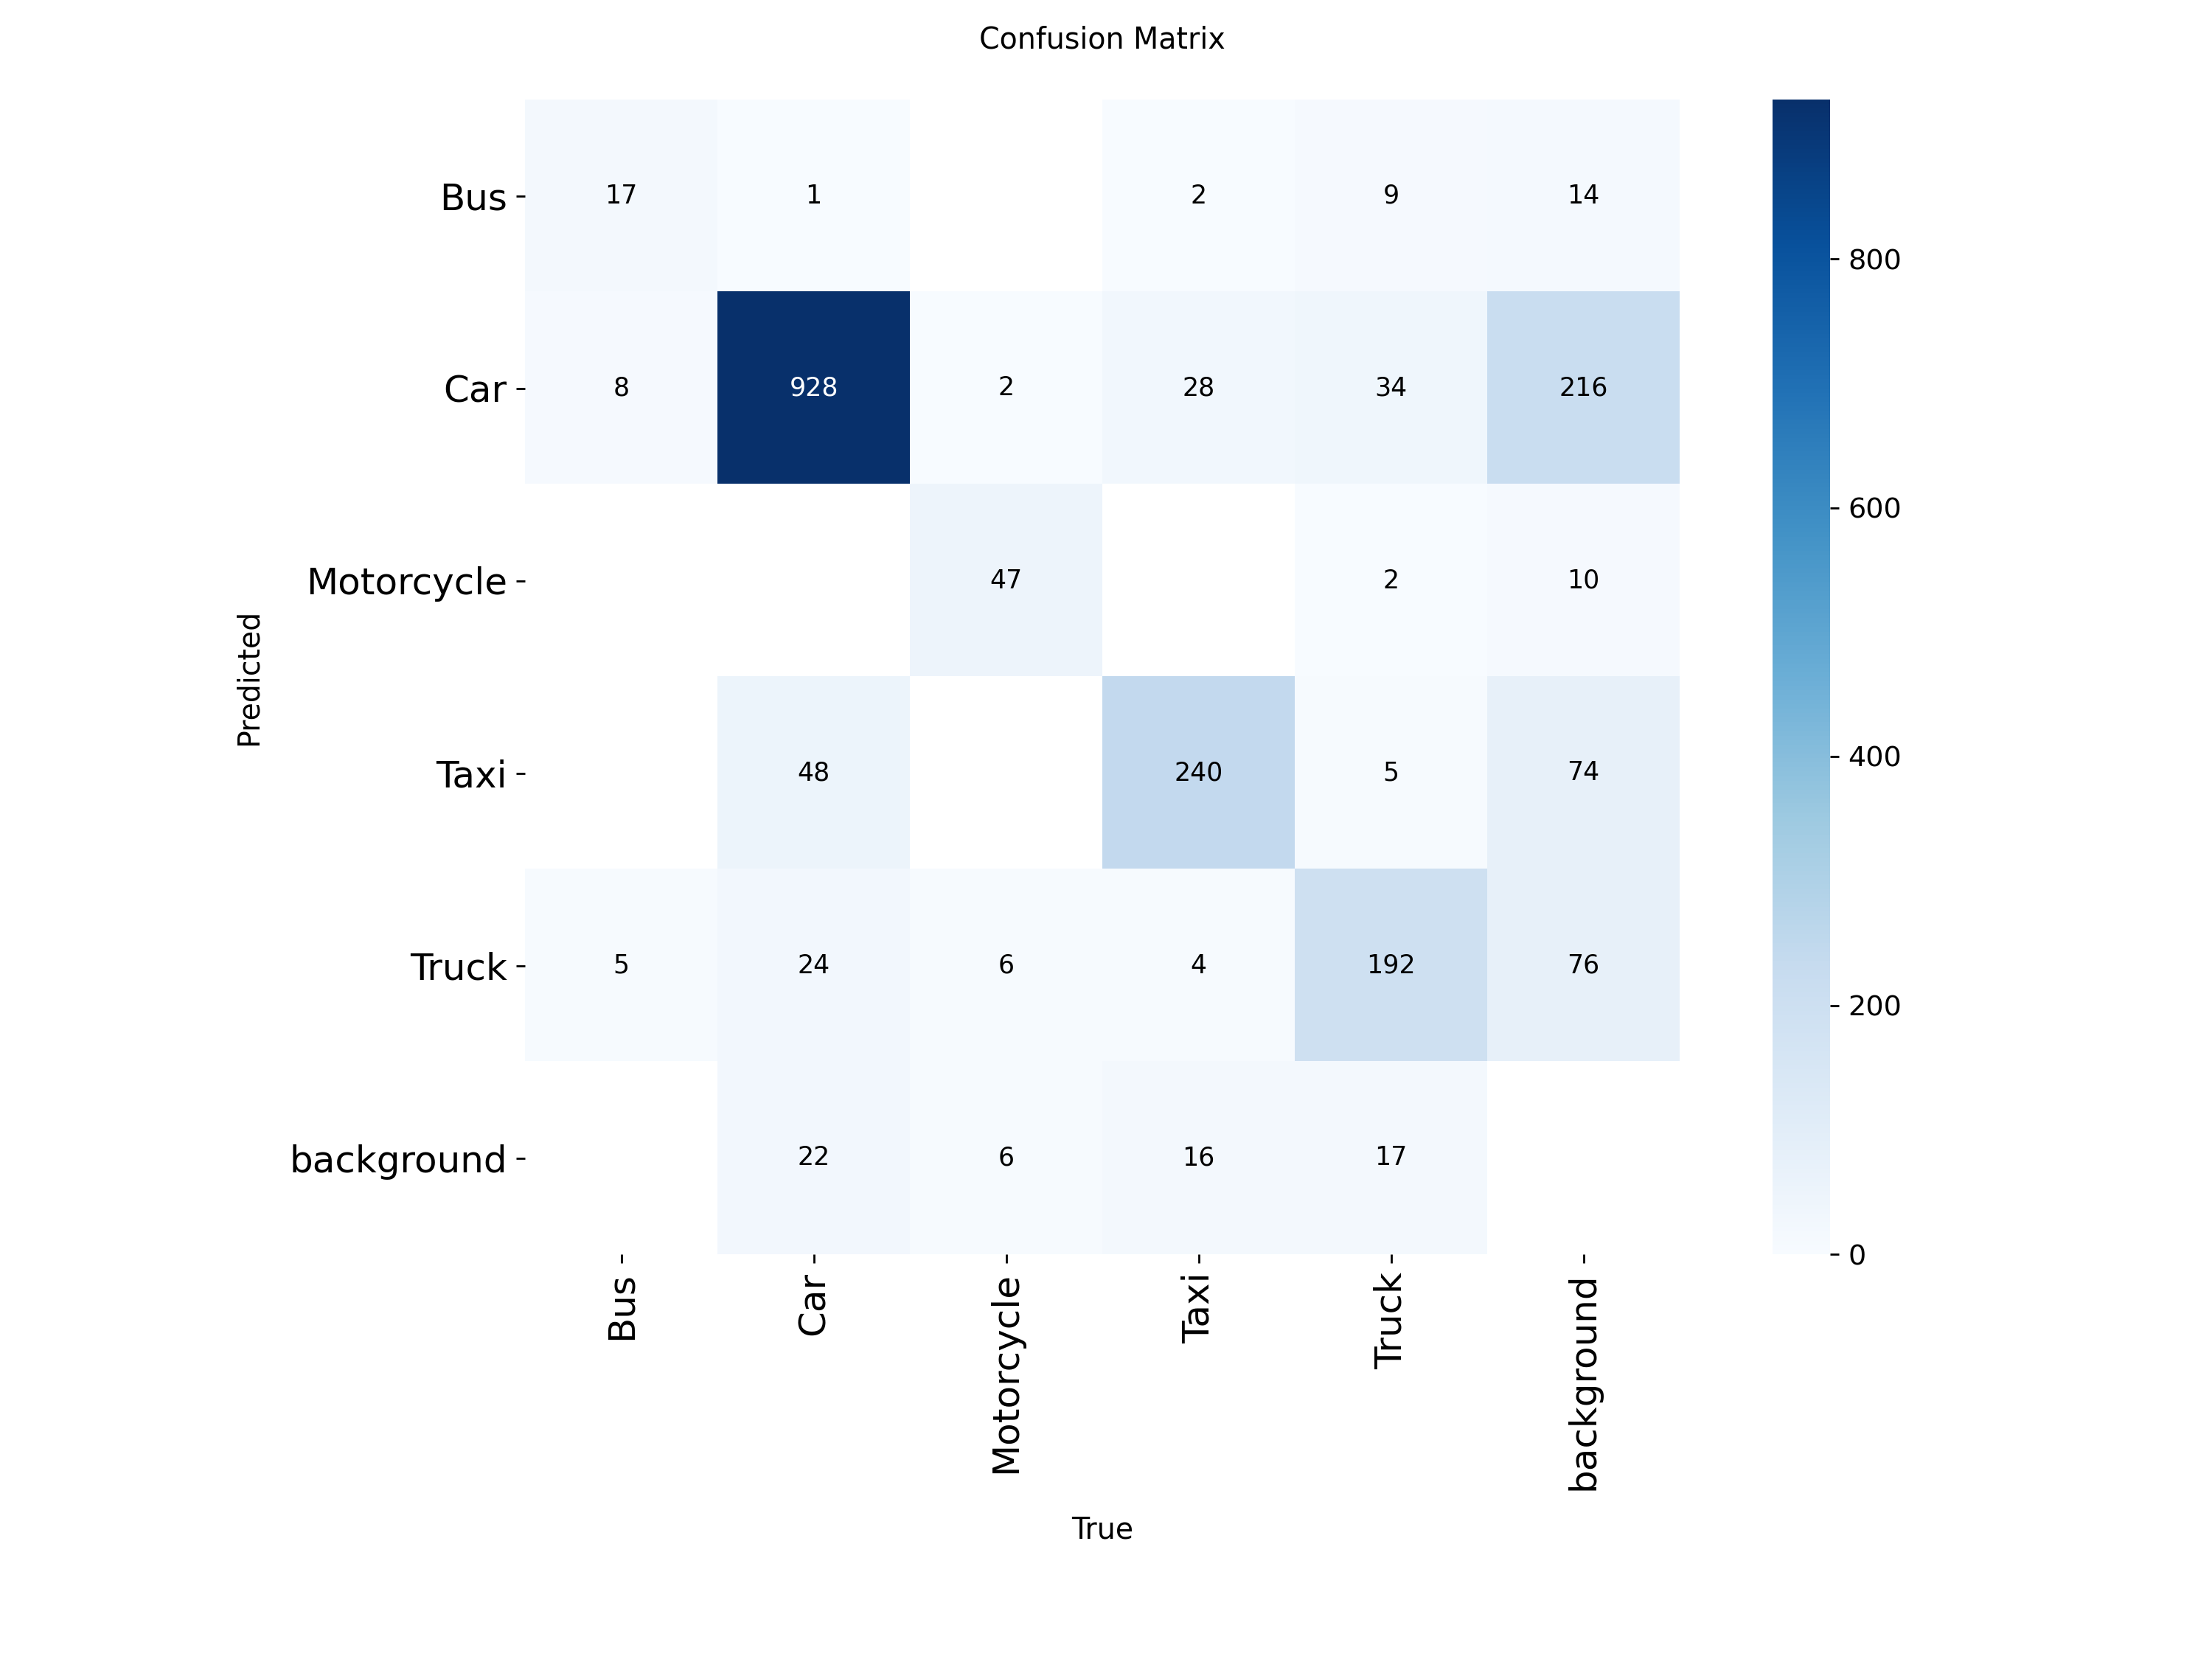

In [15]:
Image(filename='runs/detect/train/confusion_matrix.png', width=600)

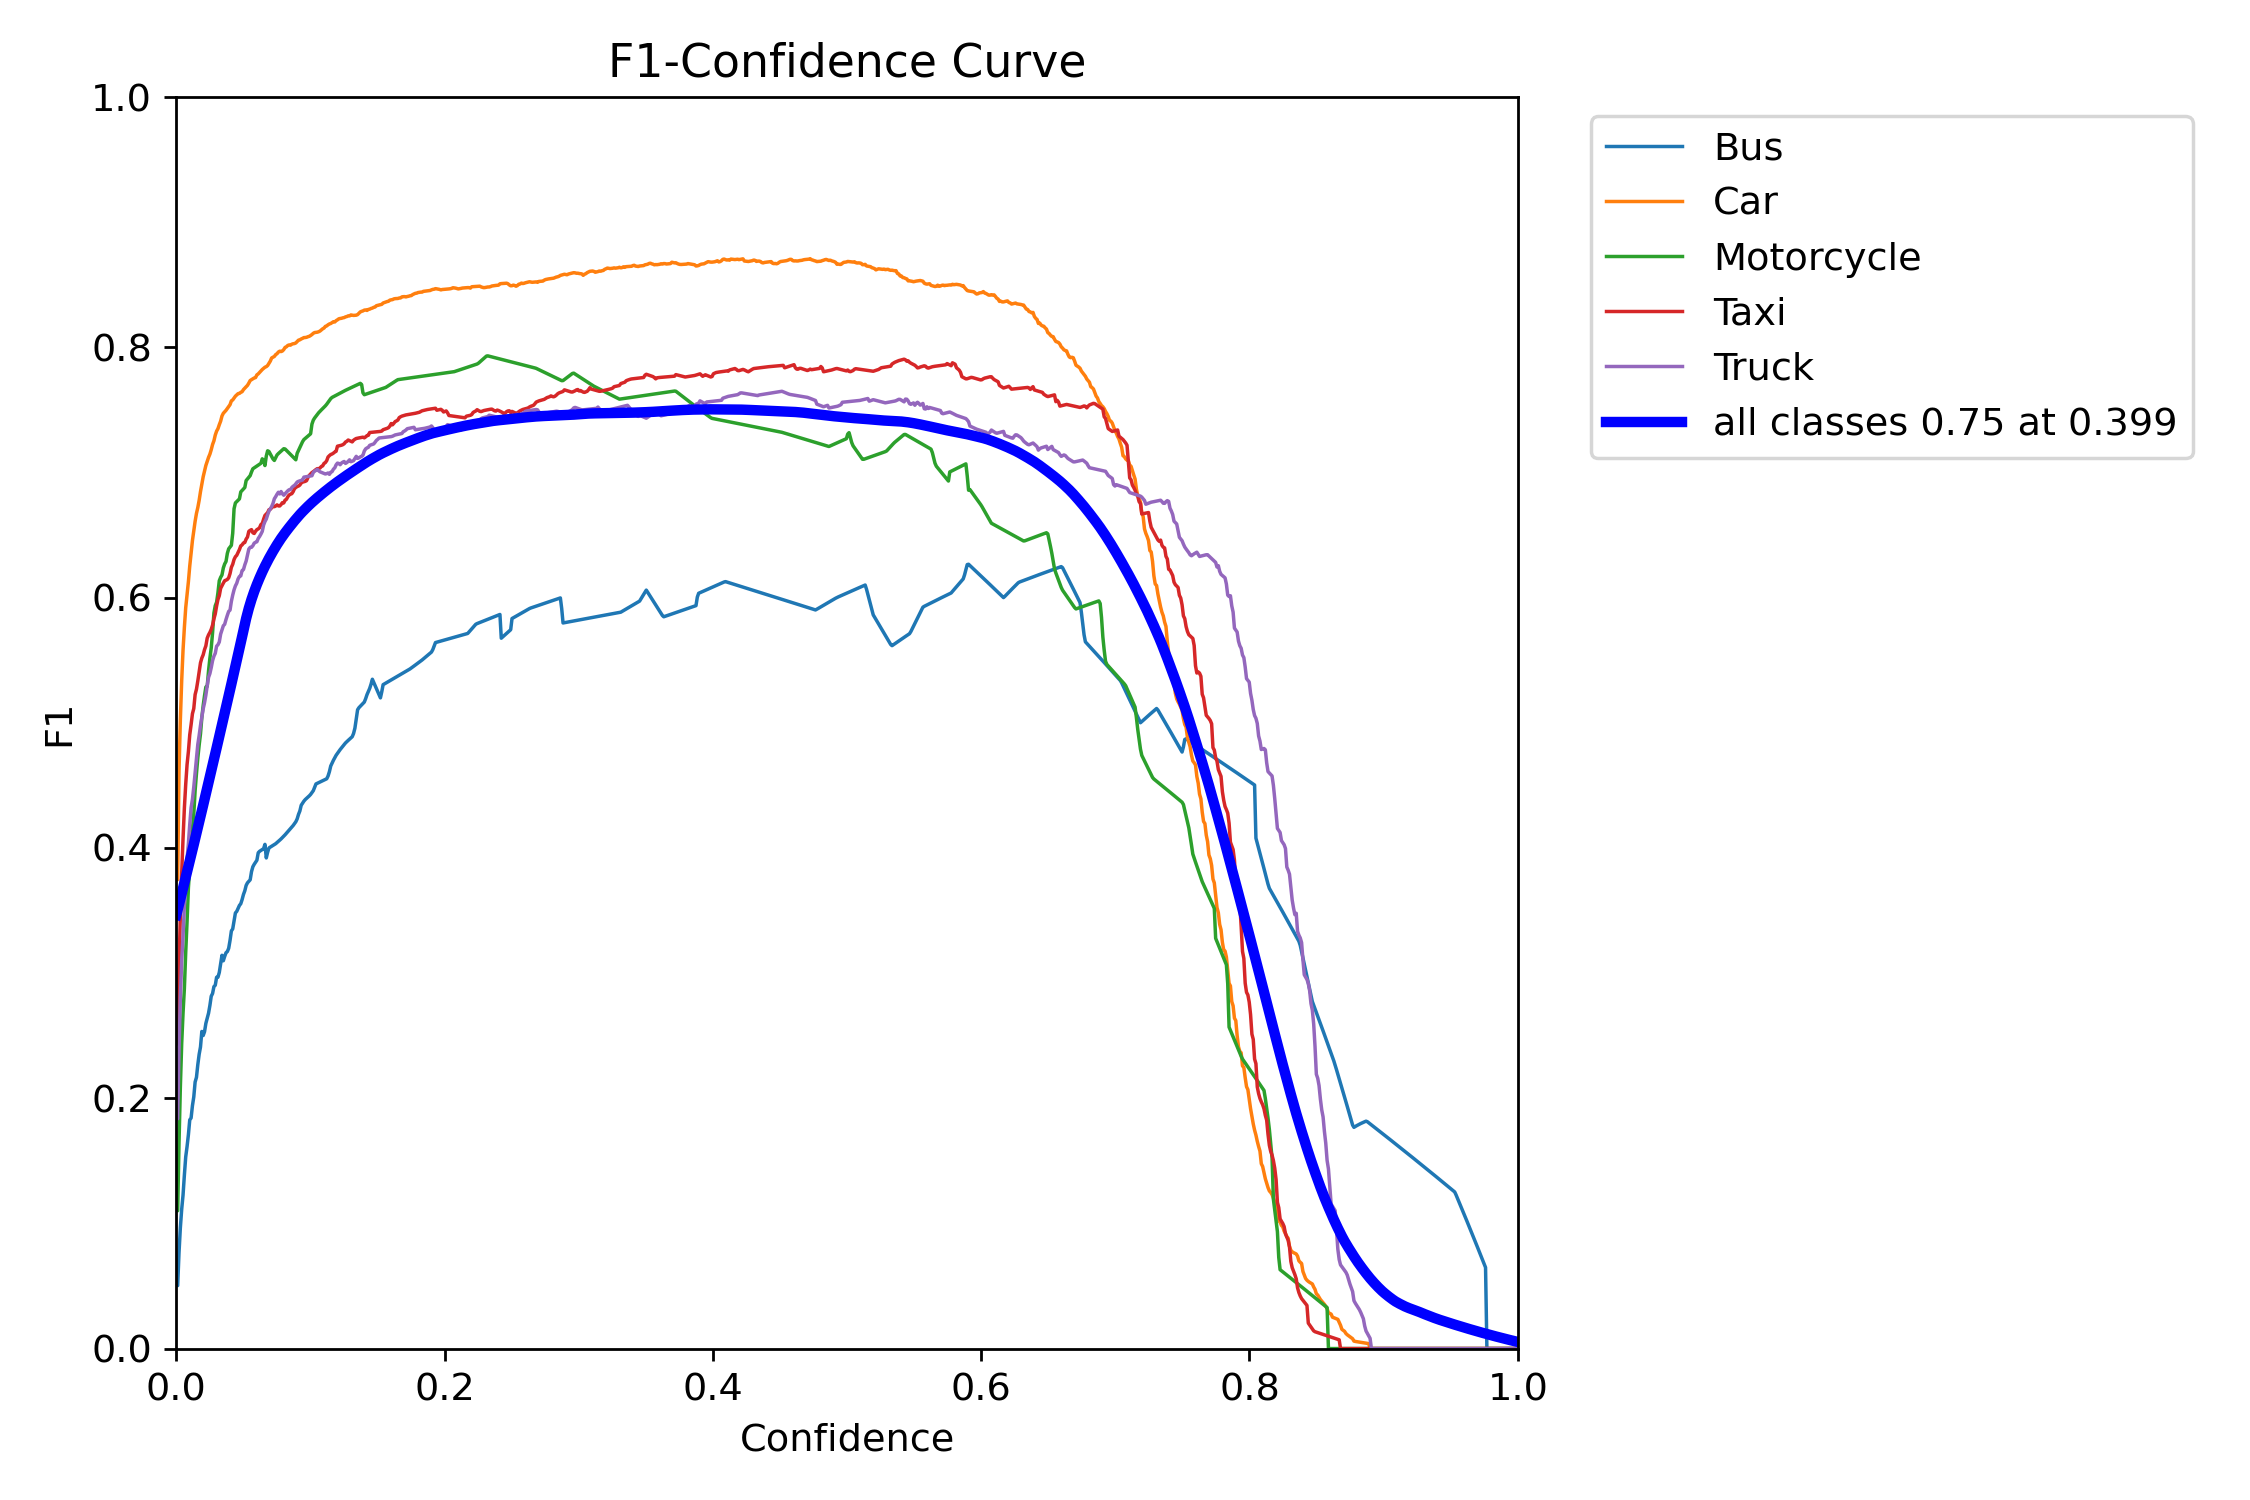

In [16]:
Image(filename='runs/detect/train/BoxF1_curve.png', width=600)

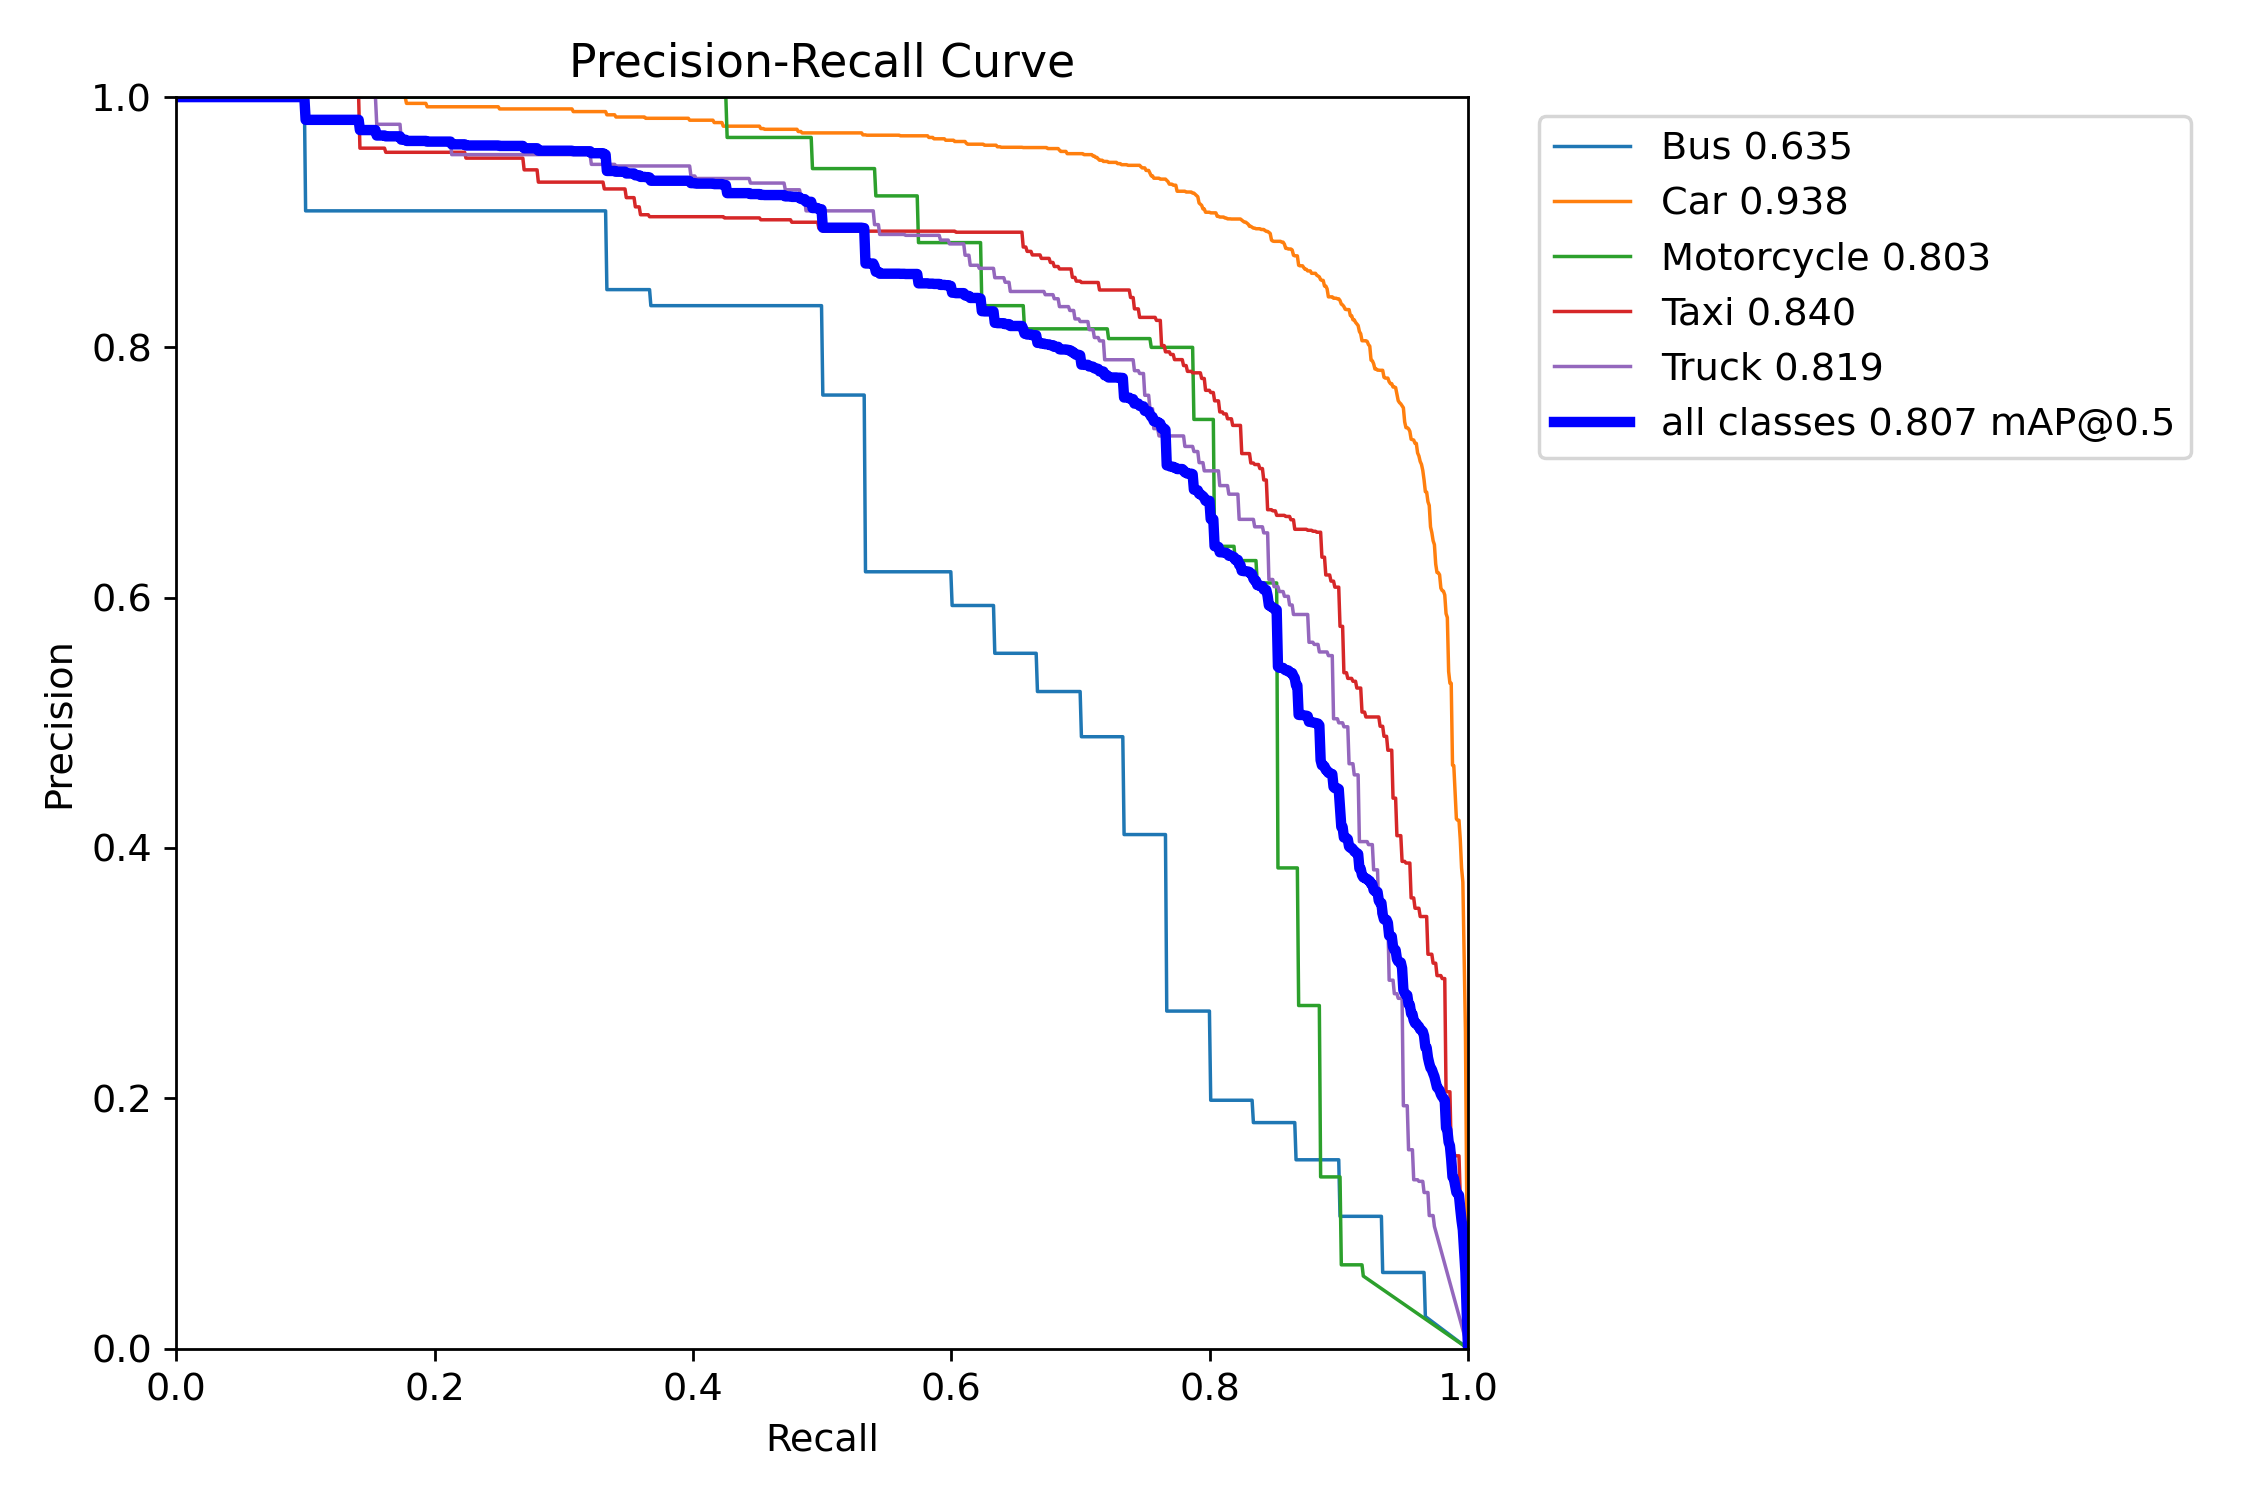

In [17]:
Image(filename='runs/detect/train/BoxPR_curve.png', width=600)

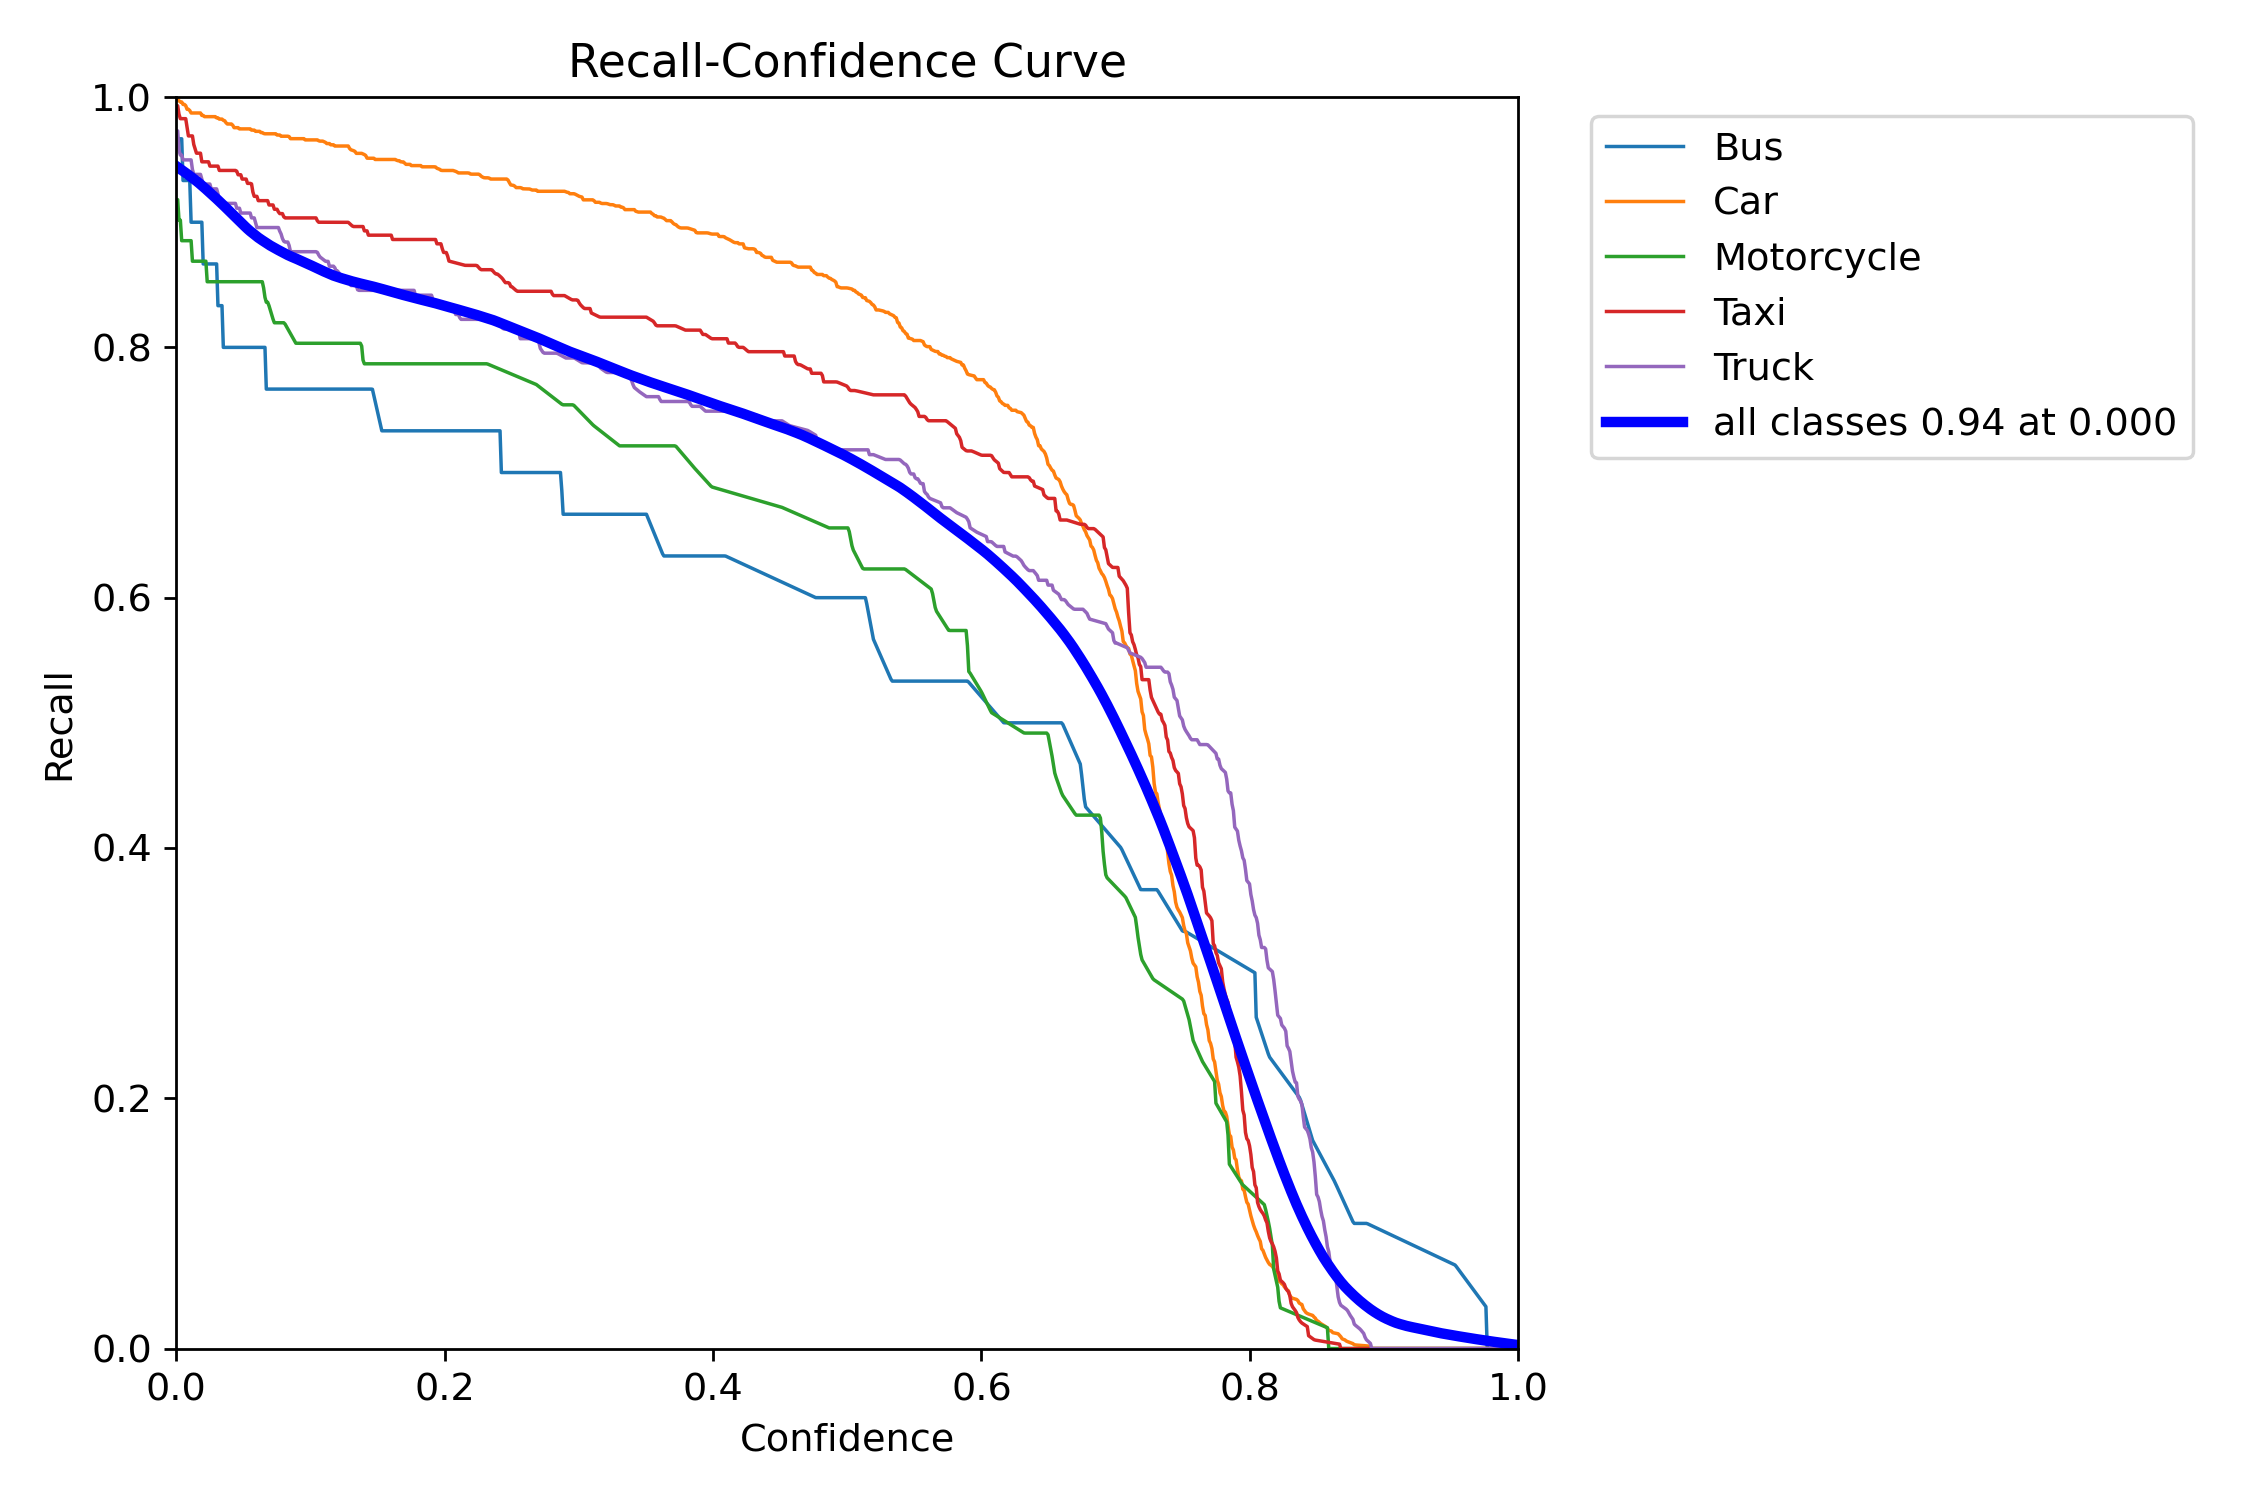

In [18]:
Image(filename='runs/detect/train/BoxR_curve.png', width=600)

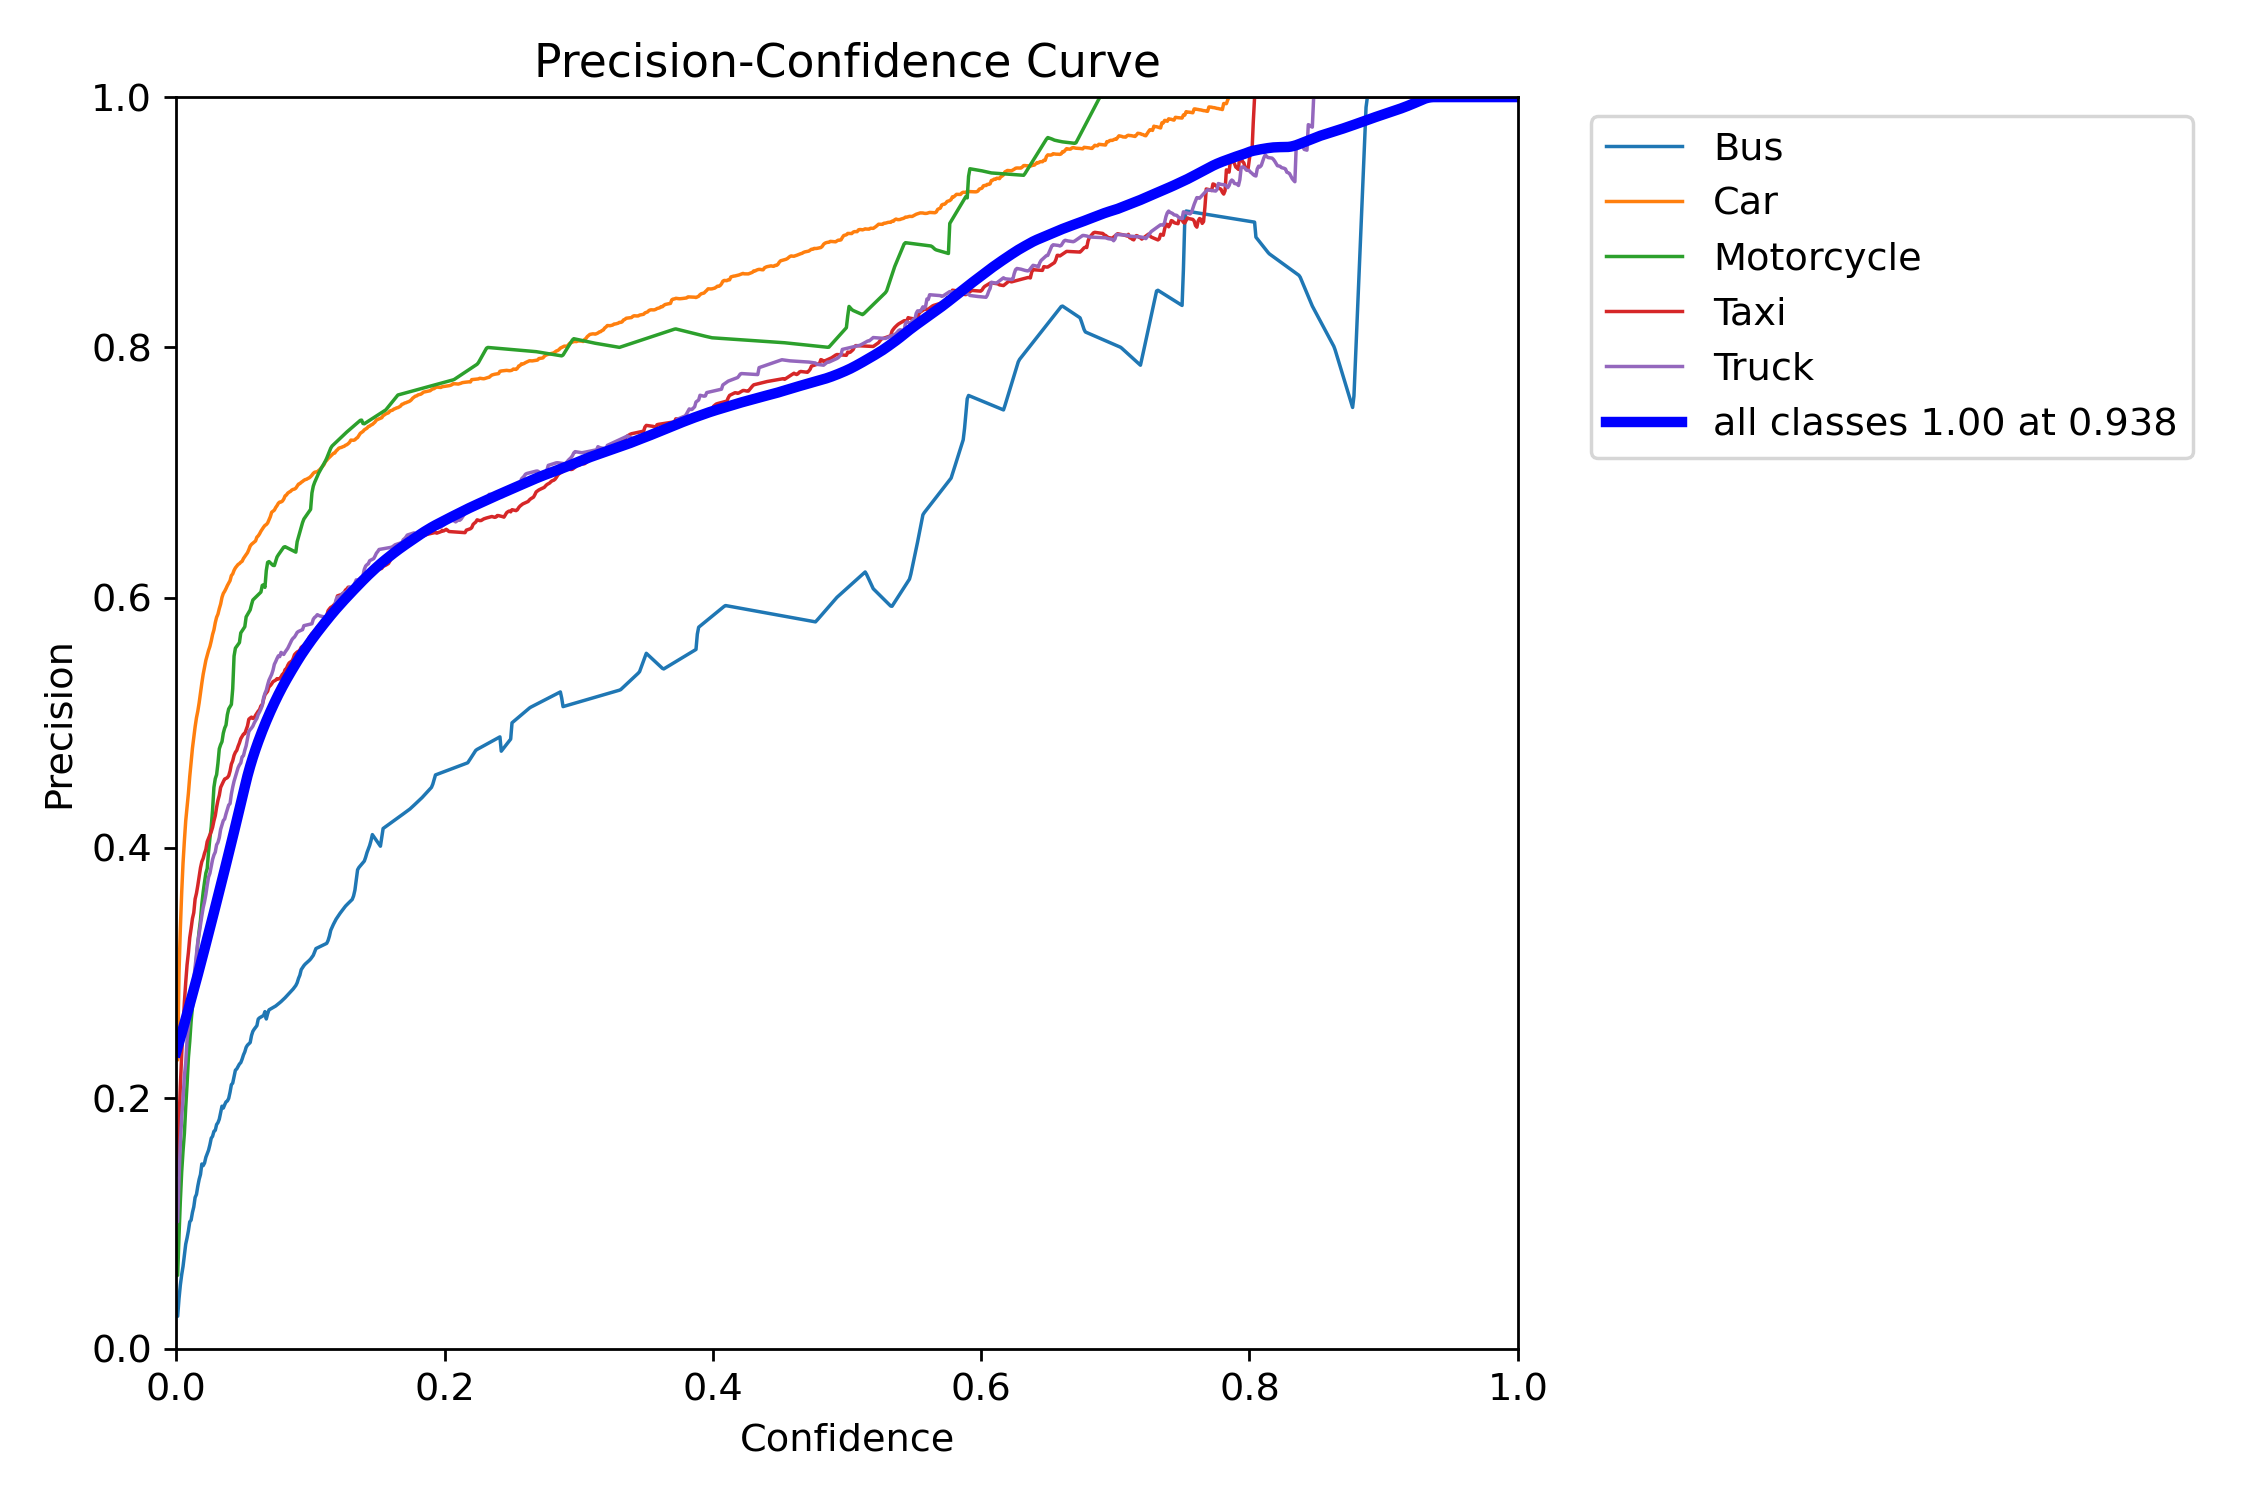

In [19]:
Image(filename='runs/detect/train/BoxP_curve.png', width=600)

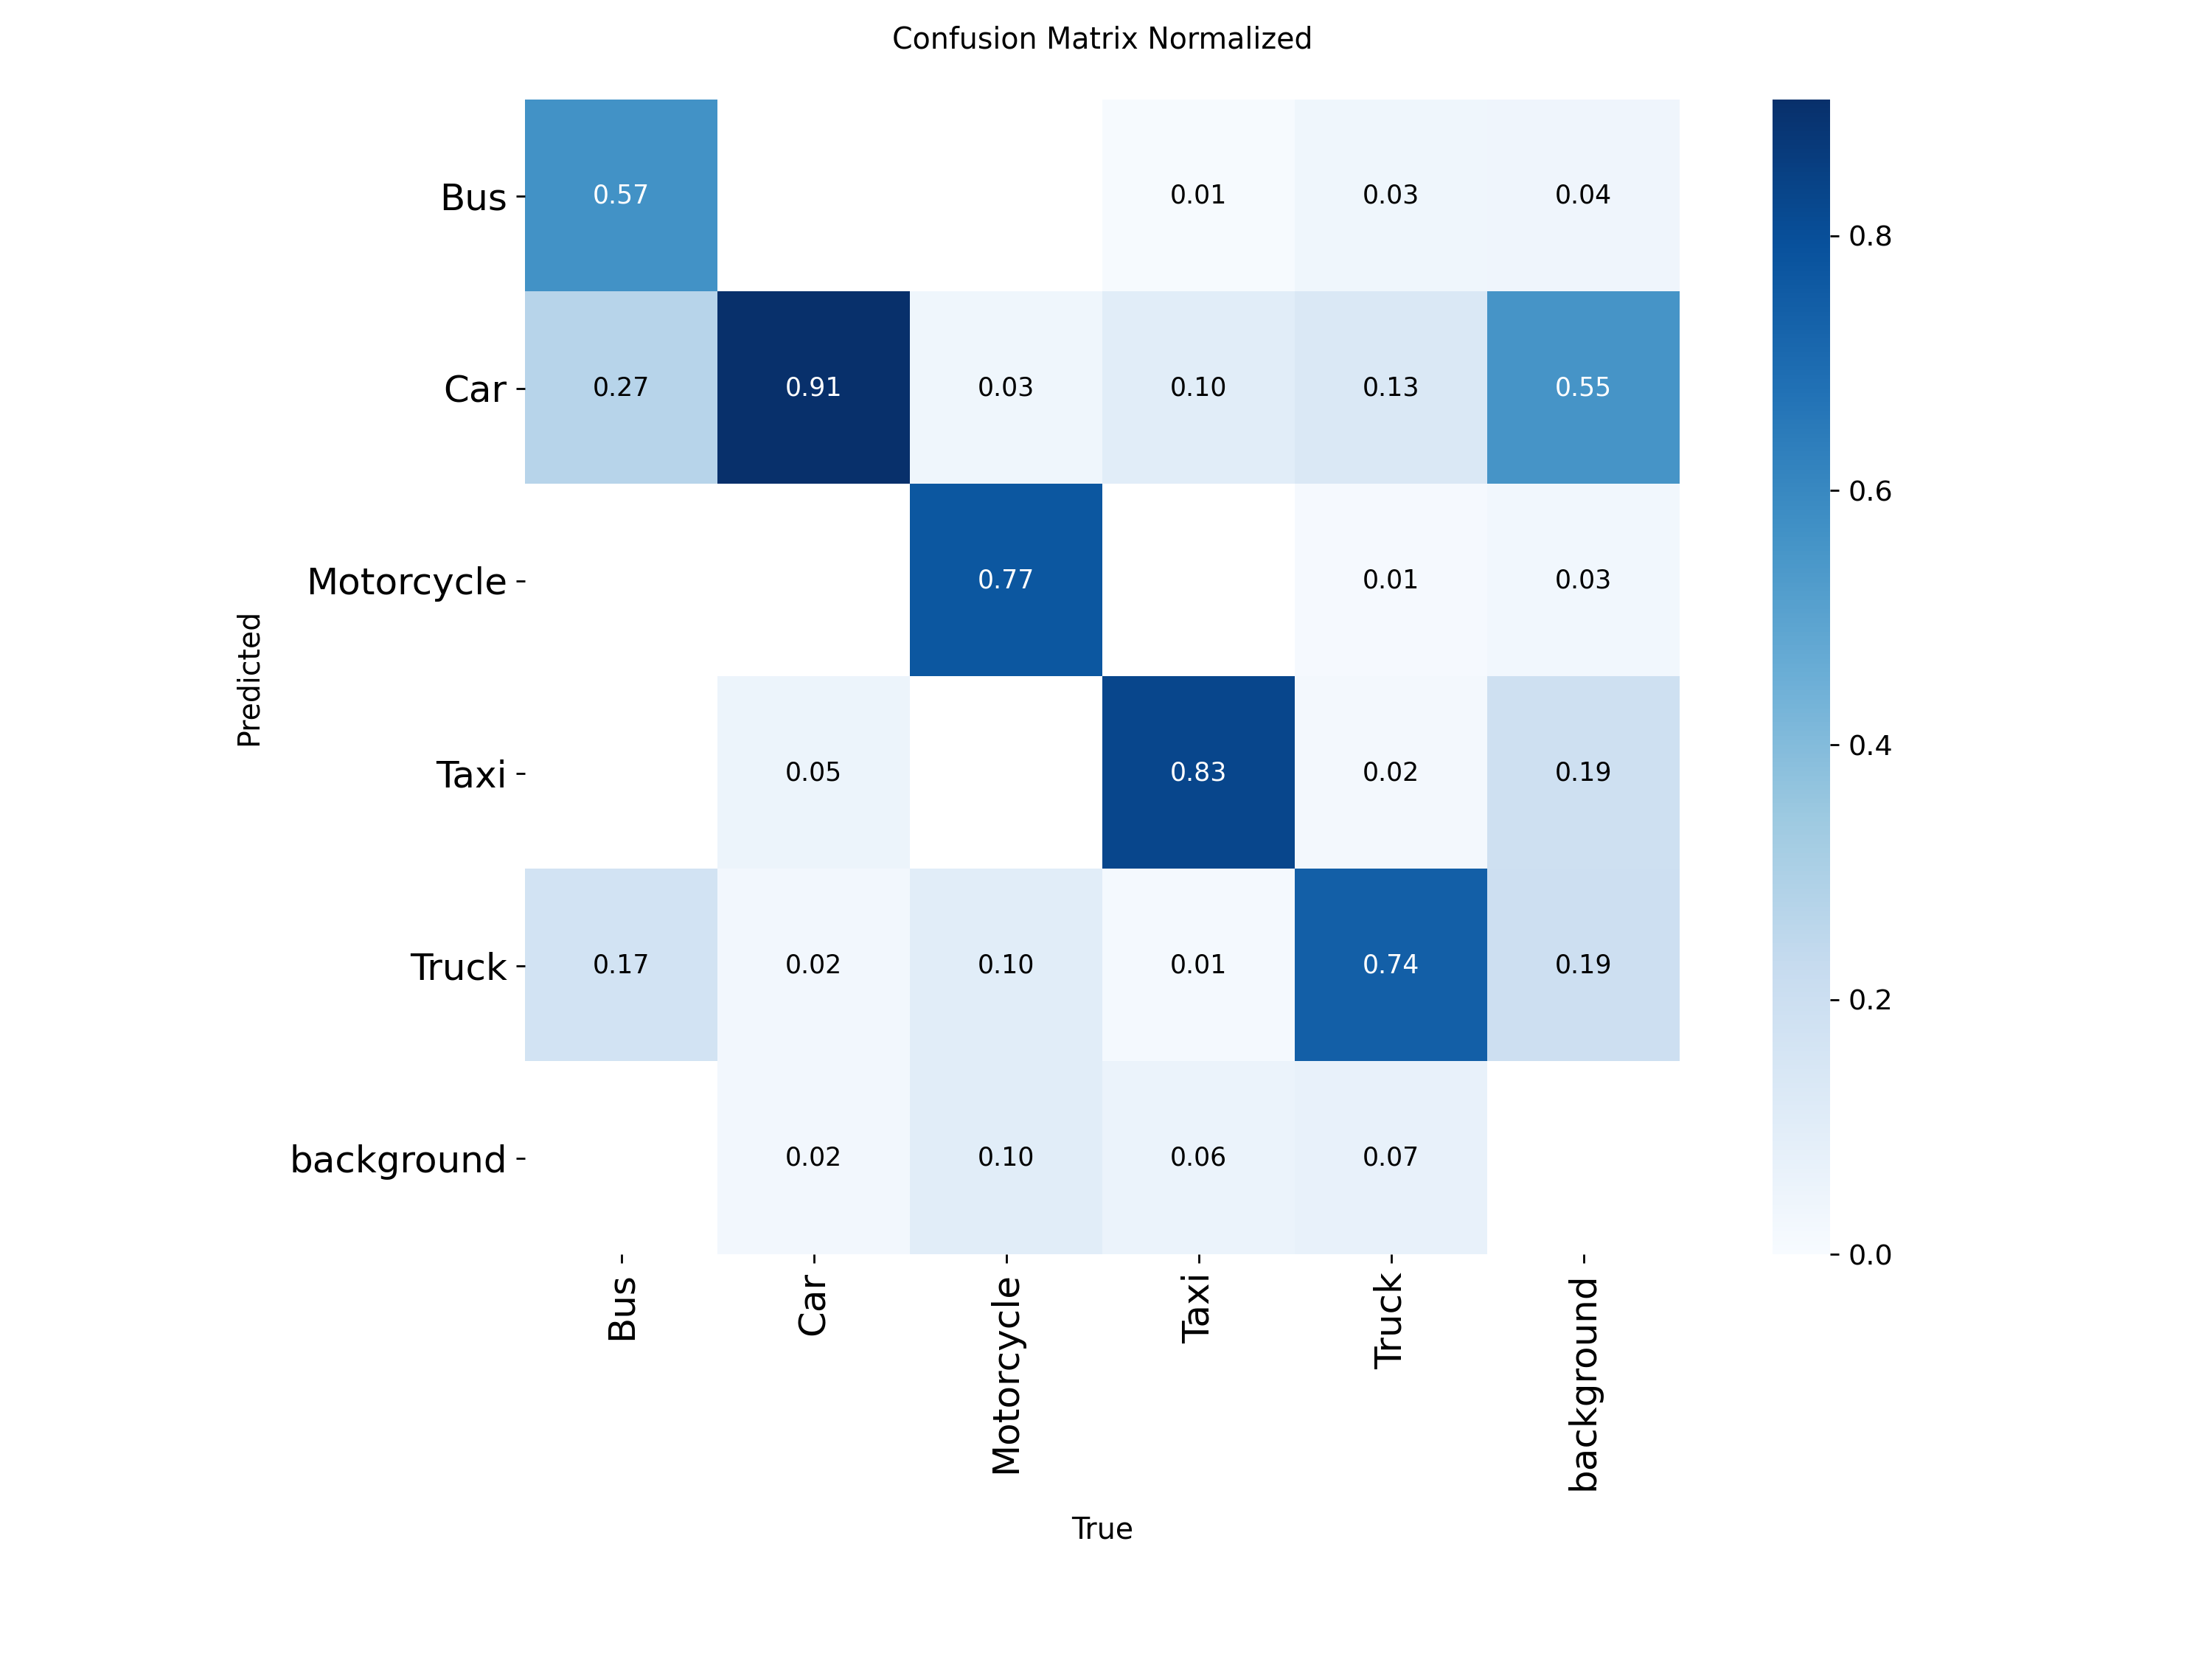

In [20]:
Image(filename='runs/detect/train/confusion_matrix_normalized.png', width=600)

In [22]:
!yolo task=detect mode=val model="runs/detect/train/weights/best.pt" data="UAV-Vehicle-Images-9/data.yaml"

Ultralytics 8.3.240 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5905MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1517.4±2063.9 MB/s, size: 104.8 KB)
val: Scanning /home/ozzaann/learn-yolo/UAV-Vehicle-Images-9/valid/labels.cache... 430 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 430/430 8.0Mit/s 0.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 10.7it/s 2.5s0.1s
                   all        430       1663      0.758       0.75      0.807      0.472
                   Bus         30         30      0.589      0.633      0.634      0.382
                   Car        295       1023      0.858      0.884      0.938      0.561
            Motorcycle         55         61      0.807      0.686      0.803      0.364
                  Taxi        153        290      0.761      0.803       0.84 

In [24]:
!yolo task=detect mode=predict model="runs/detect/train/weights/best.pt" source="test-sample/testing-car.jpg" save=True

Ultralytics 8.3.240 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5905MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /home/ozzaann/learn-yolo/test-sample/testing-car.jpg: 320x640 1 Truck, 41.1ms
Speed: 1.3ms preprocess, 41.1ms inference, 16.6ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /home/ozzaann/learn-yolo/runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict
